# Degree, Error, and Boundedness Tradeoffs

QSVT-style polynomial design has two practical constraints: approximate the
target function well and stay bounded on the relevant interval.

This notebook sweeps a few degrees and compares the diagnostics returned by the
package design helpers.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from qsvt.design import (
    design_filter_diagnostics,
    design_interval_projector_diagnostics,
    design_inverse_diagnostics,
    design_sign_diagnostics,
    design_sqrt_diagnostics,
)
from qsvt.qsvt import qsvt_compatibility_report

## Sweep Several Design Families

Each row records the sampled fit error, boundedness margin, degree, and parity.
The smaller sample grids keep this notebook fast while preserving the qualitative
tradeoff.

In [2]:
builders = {
    "sign": lambda degree: design_sign_diagnostics(
        gamma=0.25,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "inverse": lambda degree: design_inverse_diagnostics(
        gamma=0.3,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "sqrt": lambda degree: design_sqrt_diagnostics(
        a=0.15,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "filter": lambda degree: design_filter_diagnostics(
        cutoff=0.45,
        sharpness=10.0,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
    "interval": lambda degree: design_interval_projector_diagnostics(
        lower=-0.35,
        upper=0.25,
        sharpness=10.0,
        degree=degree,
        num_points=401,
        bounded_num_points=801,
    ),
}

degrees = [3, 5, 7, 9, 11]
records = []
for name, builder in builders.items():
    for degree in degrees:
        report = builder(degree)
        compatibility = qsvt_compatibility_report(
            report["coeffs"],
            bounded_num_points=801,
            attempt_synthesis=False,
        )
        records.append(
            {
                "name": name,
                "degree": degree,
                "max_error": report["max_error"],
                "bounded_margin": report["bounded_margin"],
                "parity": compatibility["parity"],
                "is_bounded": compatibility["is_bounded"],
            }
        )

for row in records[::5]:
    print(row)

{'name': 'sign', 'degree': 3, 'max_error': 0.5479390083498441, 'bounded_margin': 0.0, 'parity': 'odd', 'is_bounded': True}
{'name': 'inverse', 'degree': 3, 'max_error': 0.9891744832830782, 'bounded_margin': 0.19626525973398778, 'parity': 'odd', 'is_bounded': True}
{'name': 'sqrt', 'degree': 3, 'max_error': 0.06978117084971214, 'bounded_margin': 0.0, 'parity': 'mixed', 'is_bounded': True}
{'name': 'filter', 'degree': 3, 'max_error': 0.5406810051779463, 'bounded_margin': 0.0, 'parity': 'even', 'is_bounded': True}
{'name': 'interval', 'degree': 3, 'max_error': 0.43277073526115417, 'bounded_margin': 0.3587275209688906, 'parity': 'mixed', 'is_bounded': True}


## Error Usually Falls With Degree

The trend is not perfectly monotone for every bounded fit, but the plot gives a
quick first pass at degree selection.

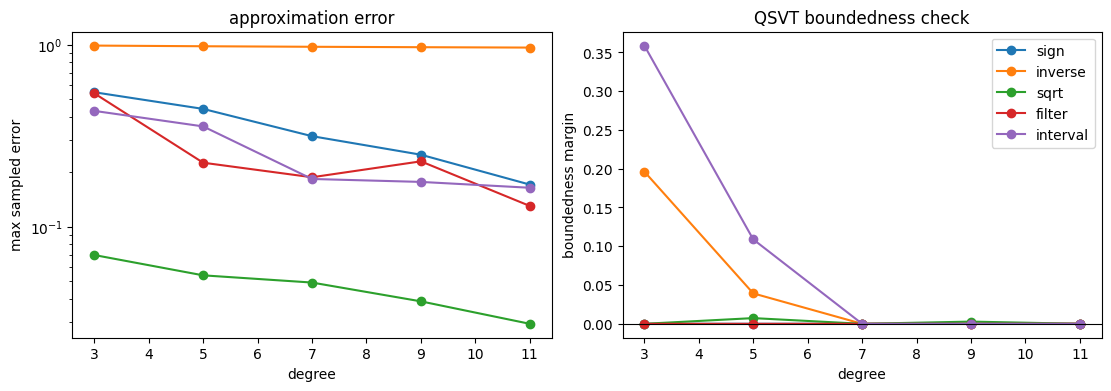

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for name in builders:
    subset = [row for row in records if row["name"] == name]
    axes[0].plot(
        [row["degree"] for row in subset],
        [row["max_error"] for row in subset],
        marker="o",
        label=name,
    )
    axes[1].plot(
        [row["degree"] for row in subset],
        [row["bounded_margin"] for row in subset],
        marker="o",
        label=name,
    )

axes[0].set_yscale("log")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("max sampled error")
axes[0].set_title("approximation error")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("degree")
axes[1].set_ylabel("boundedness margin")
axes[1].set_title("QSVT boundedness check")
axes[1].legend(loc="best")

## Inspect One Chosen Design

After narrowing the degree sweep, inspect the target, approximation, and error
curves for a specific family.

max error: 0.1632978061045941
bounded margin: 1.1102230246251565e-16


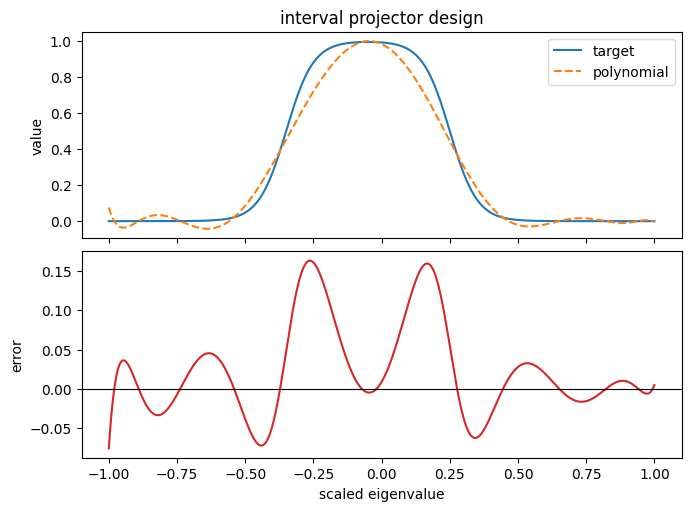

In [4]:
chosen = design_interval_projector_diagnostics(
    lower=-0.35,
    upper=0.25,
    sharpness=10.0,
    degree=11,
    num_points=801,
    bounded_num_points=1001,
)
xs = chosen["xs"]

fig, axes = plt.subplots(2, 1, figsize=(6.8, 5.0), sharex=True, constrained_layout=True)
axes[0].plot(xs, chosen["target_values"], label="target")
axes[0].plot(xs, chosen["polynomial_values"], "--", label="polynomial")
axes[0].set_ylabel("value")
axes[0].set_title("interval projector design")
axes[0].legend(loc="best")
axes[1].plot(xs, chosen["errors"], color="tab:red")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("scaled eigenvalue")
axes[1].set_ylabel("error")

print("max error:", chosen["max_error"])
print("bounded margin:", chosen["bounded_margin"])
assert chosen["bounded_margin"] > -1e-10